# Bigframes quickstart

BigQuery DataFrames provides a Pythonic DataFrame and machine learning (ML) API powered by the BigQuery engine.

- bigframes.pandas provides a pandas-compatible API for analytics.
- bigframes.ml provides a scikit-learn-like API for ML.

BigQuery DataFrames is an open-source package.
    
Read more at: [BigQuery DataFrames](https://cloud.google.com/python/docs/reference/bigframes/latest)

In [2]:
import bigframes.pandas as bpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# Settings based on your plugin configurations. You can change these settings below.
PROJECT_ID = 'proj-docai-dev'
REGION = 'us'

bpd.options.bigquery.project = PROJECT_ID
#bpd.options.bigquery.location = REGION


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def display_column_distribution(df, column_name, plot_type='auto'):
    """
    Displays the distribution of a column in a DataFrame, with optional label sorting.

    Args:
        df (pd.DataFrame): The DataFrame containing the column.
        column_name (str): The name of the column to display.
        plot_type (str, optional): The type of plot to use ('auto', 'hist', 'kde', 'box', 'count', 'bar'). Defaults to 'auto'.
    """

    if column_name not in df.columns:
        print(f"Column '{column_name}' not found in the DataFrame.")
        return

    column_data = df[column_name]

    if plot_type == 'auto':
        if pd.api.types.is_numeric_dtype(column_data):
            # Numerical data: choose histogram or KDE
            if len(column_data.unique()) > 20: #heuristic, adjust as needed
                plot_type = 'hist'
            else:
                plot_type = 'bar' #if low number of unique numericals, a bar chart is better.
        else:
            # Categorical data: choose countplot
            plot_type = 'count'

    plt.figure(figsize=(10, 6))

    if plot_type == 'hist':
        sns.histplot(column_data, kde=True)
        plt.title(f'Distribution of {column_name} (Histogram)')
        plt.xlabel(column_name)
        plt.ylabel('Frequency')
    elif plot_type == 'kde':
        sns.kdeplot(column_data, fill=True)
        plt.title(f'Distribution of {column_name} (KDE)')
        plt.xlabel(column_name)
        plt.ylabel('Density')
    elif plot_type == 'box':
        sns.boxplot(y=column_data)
        plt.title(f'Distribution of {column_name} (Boxplot)')
        plt.ylabel(column_name)
    elif plot_type == 'count':
        # Sort labels alphabetically
        sorted_counts = column_data.value_counts().sort_index()
        sns.countplot(x=column_data, order=sorted_counts.index)
        plt.title(f'Distribution of {column_name} (Countplot)')
        plt.xlabel(column_name)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right') #rotate if labels are long
    elif plot_type == 'bar':
        # Sort labels alphabetically
        sorted_counts = column_data.value_counts().sort_index()
        sorted_counts.plot(kind='bar')
        plt.title(f'Distribution of {column_name} (Barplot)')
        plt.xlabel(column_name)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')

    plt.tight_layout() #prevents labels from being cut off
    plt.show()

In [5]:
query= f'''SELECT
  t.*,
  SAFE_CAST(t.Valuation_Value AS FLOAT64) AS NumericValuation,
  address.`ns0:AddressLine1` as AddresLine1,
  address.`ns0:AddressLine2` as AddressLine2,
  address.`ns0:City` as City,
  address.`ns0:CountryRegion` as Country,
  address.`ns0:County` as County,
  address.`ns0:StateProvince` as State,
  address.`ns0:ZipPostalCode` as Zipcode,
  address.`ns0:Latitude` as Latitude,
  address.`ns0:Longitude` as Longitude
FROM
  `sales_rec_demo.cc_data_total` AS t,
  UNNEST(t.Addresses_Address) AS address
WHERE
  SAFE_CAST(t.Valuation_Value AS FLOAT64) > 1000000
  AND t.Stage IN ("Biddate Set", "Construction Documents", "General Contractor Award", "Low Bids Announced", "SUBBIDS: ASAP", "Construction Underway", "Post Bid")
  AND t.ParentCategories_PrimaryCategoryName IN (
    "Airport", "Apartments", "Auditoriums", "Bank", "College", "University", "Condominiums", "Courthouses", "Dormitories", "Elementary, Pre Schools", "Fire and Police Stations", "Food Stores", "Government - Misc. Bldgs.", "Government Offices", "High Schools", "Hospitals, Clinics", "Hotels", "Junior High Schools", "Libraries", "Medical Offices", "Military - Misc.", "Military Housing", "Military Offices", "Museums", "Nursing Homes", "Offices", "Post Offices", "Prisons", "Religious Auditoriums", "Rental Warehouses", "Restaurants", "Retail Stores", "Shopping Centers", "Special, Vocational Schools", "Sports Arenas/Convention Centers", "Warehouses", "Athletic Bldgs", "Automotive", "Cafeterias", "Clubs, Community Centers", "Entertainment", "Golf Course / Country Club", "Laboratories", "Transportation Terminals", "Water and Sewage Treatment Plants"
  )
  AND EXISTS (
    SELECT
      1
    FROM
      UNNEST(t.ParentCategories_ParentCategory) AS pc,
      UNNEST(pc.`ns0:SubCategories`.`ns0:SubCategory`) AS sub
    WHERE
      sub IN (
        "Airport", "Offices", "Transportation Terminals", "Rental Warehouses", "Museums", "Sports Arenas/Convention Centers", "Libraries", "Auditoriums", "Religious Auditoriums", "Elementary, Pre Schools, High Schools, Junior High Schools, Special, Vocational Schools", "College, University", "Clubs, Community Centers", "Athletic Bldgs", "Cafeterias", "Dormitories", "Courthouses", "Fire and Police Stations", "Prisons", "Government - Misc. Bldgs.", "Government Offices", "Post Offices", "Broadcast Studios", "Warehouses", "Laboratories", "Hospitals, Clinics", "Medical Offices", "Manufacturing"
      )
  );'''

filtered_main = bpd.read_gbq(query)


In [34]:
filtered_main

,ProjectID,DataSourceID,Title,Stage,URL,UpdateDate,IsProspective,UpdateText,Valuation_Value,Valuation_Currency,...,NumericValuation,AddresLine1,AddressLine2,City,Country,County,State,Zipcode,Latitude,Longitude
0,1005909122,US,RFP D/B - Demo Building 51 Musculo-Skeletal Ce...,Construction Documents,http://insight.cmdgroup.com/SingleSignOn/Proje...,2023-06-02,False,Updated to Construction Documents stage,5000000.00,USD,...,5000000.0,3801 Miranda Ave,<NA>,Palo Alto,UNITED STATES,Santa Clara,CA,94304,37.408130000,-122.158663000
1,1005318816,US,Austin FC Stadium at McKalla Place - Bid Packa...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-04-01,False,"Project reviewed, Stage confirmed as General C...",200000000.00,USD,...,200000000.0,10414 Mc Kalla Pl,<NA>,Austin,UNITED STATES,Travis,TX,78758,30.378845000,-97.711093000
2,1005318816,US,Austin FC Stadium at McKalla Place - Bid Packa...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-04-01,False,"Project reviewed, Stage confirmed as General C...",200000000.00,USD,...,200000000.0,10414 Mc Kalla Pl,<NA>,Austin,UNITED STATES,Travis,TX,78758,30.378845000,-97.711093000
3,1005318816,US,Austin FC Stadium at McKalla Place - Bid Packa...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-04-01,False,"Project reviewed, Stage confirmed as General C...",200000000.00,USD,...,200000000.0,10414 Mc Kalla Pl,<NA>,Austin,UNITED STATES,Travis,TX,78758,30.378845000,-97.711093000
4,1005318816,US,Austin FC Stadium at McKalla Place - Bid Packa...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-04-01,False,"Project reviewed, Stage confirmed as General C...",200000000.00,USD,...,200000000.0,10414 Mc Kalla Pl,<NA>,Austin,UNITED STATES,Travis,TX,78758,30.378845000,-97.711093000
5,1006083512,US,Poder Learning Center,Construction Underway,http://insight.cmdgroup.com/SingleSignOn/Proje...,2022-06-07,False,Scalaplus was added as Architect,2750000.00,USD,...,2750000.0,3357 W 55th St,<NA>,Chicago,UNITED STATES,Cook,IL,60632,41.808605000,-87.711782000
6,1006866827,US,Construction Services for the Building Additio...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-06-14,False,"Project reviewed, Stage confirmed as General C...",2949000.00,USD,...,2949000.0,26 E Grand Ave,<NA>,Fox Lake,UNITED STATES,Lake,IL,60020,42.394881000,-88.176816000
7,1007200051,CAN,RFQ Contractor D/B - Richmond Hospital Redevel...,Post Bid,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-07-11,False,Updated to Post Bid stage,1950000000.00,CAD,...,1950000000.0,7000 Westminster Hwy,<NA>,Richmond,CANADA,Greater Vancouver RD,BC,V6X 1A1,49.170240000,-123.144920000
8,1005911347,US,6200 Airport Road-Building 2 - West Jordan Ind...,Post Bid,http://insight.cmdgroup.com/SingleSignOn/Proje...,2022-06-24,False,"Project reviewed, Stage confirmed as Post Bid",10000000.00,USD,...,10000000.0,4701 W 6200 S,<NA>,Salt Lake City,UNITED STATES,Salt Lake,UT,84118,40.654603000,-111.984034000
9,1006708526,US,McCall Road Self Storage Facility,Construction Underway,http://insight.cmdgroup.com/SingleSignOn/Proje...,2023-07-18,False,Updated to Construction Underway stage,12700000.00,USD,...,12700000.0,1918 S McCall Rd,<NA>,Englewood,UNITED STATES,Sarasota,FL,34223,27.013007000,-82.380021000


In [6]:
import pickle
with open('data/curated_data/all_data.pkl', 'wb') as file:
    pickle.dump(filtered_main, file)

PicklingError: Pickling client objects is explicitly not supported.
Clients have non-trivial state that is local and unpickleable.

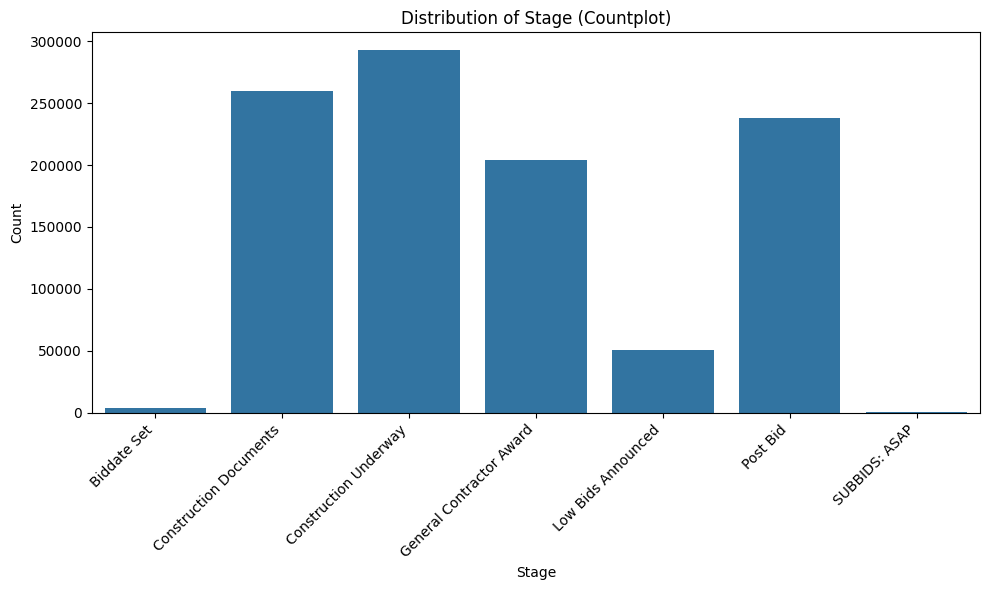

In [35]:
display_column_distribution(filtered_main, 'Stage')


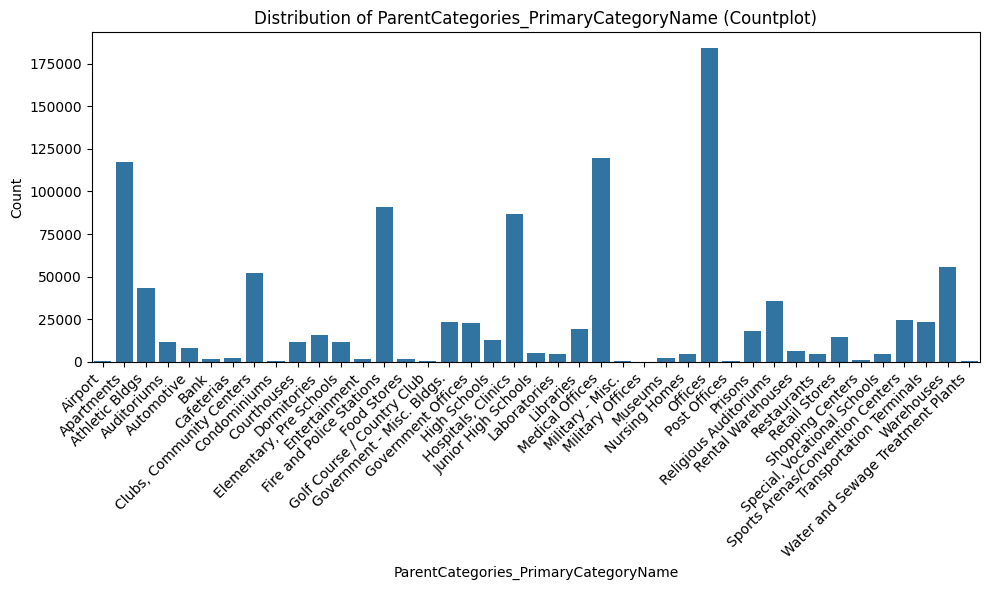

In [36]:
display_column_distribution(filtered_main, 'ParentCategories_PrimaryCategoryName')


<class 'pandas.core.series.Series'>


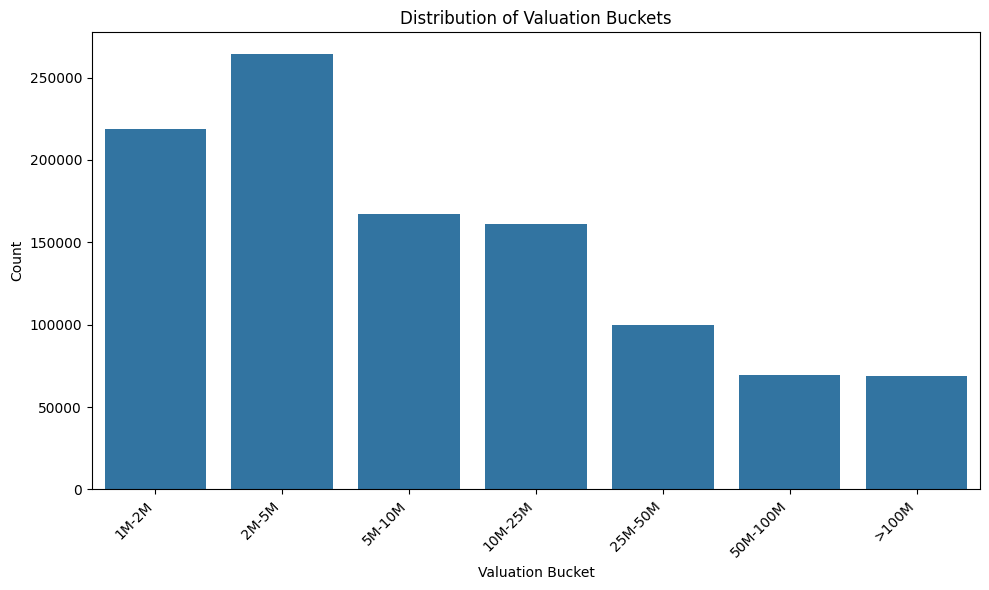

In [37]:


def bucket_and_distribute_valuation_series(valuation_series):
    """
    Buckets a Pandas Series of valuations into specified ranges and displays the distribution.

    Args:
        valuation_series (pd.Series): The Pandas Series containing the valuation values.
    """

    if not isinstance(valuation_series, pd.Series):
        raise TypeError("Input must be a Pandas Series.")

    def bucket_valuation(value):
        if value <= 2000000:
            return '1M-2M'
        elif value <= 5000000:
            return '2M-5M'
        elif value <= 10000000:
            return '5M-10M'
        elif value <= 25000000:
            return '10M-25M'
        elif value <= 50000000:
            return '25M-50M'
        elif value <= 100000000:
            return '50M-100M'
        else:
            return '>100M'

    valuation_buckets = valuation_series.apply(bucket_valuation)

    plt.figure(figsize=(10, 6))
    sns.countplot(x=valuation_buckets, order=['1M-2M', '2M-5M', '5M-10M', '10M-25M', '25M-50M', '50M-100M', '>100M'])
    plt.title('Distribution of Valuation Buckets')
    plt.xlabel('Valuation Bucket')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


valuation_column = filtered_main['NumericValuation'].to_pandas() 
print(type(valuation_column))

bucket_and_distribute_valuation_series(valuation_column)

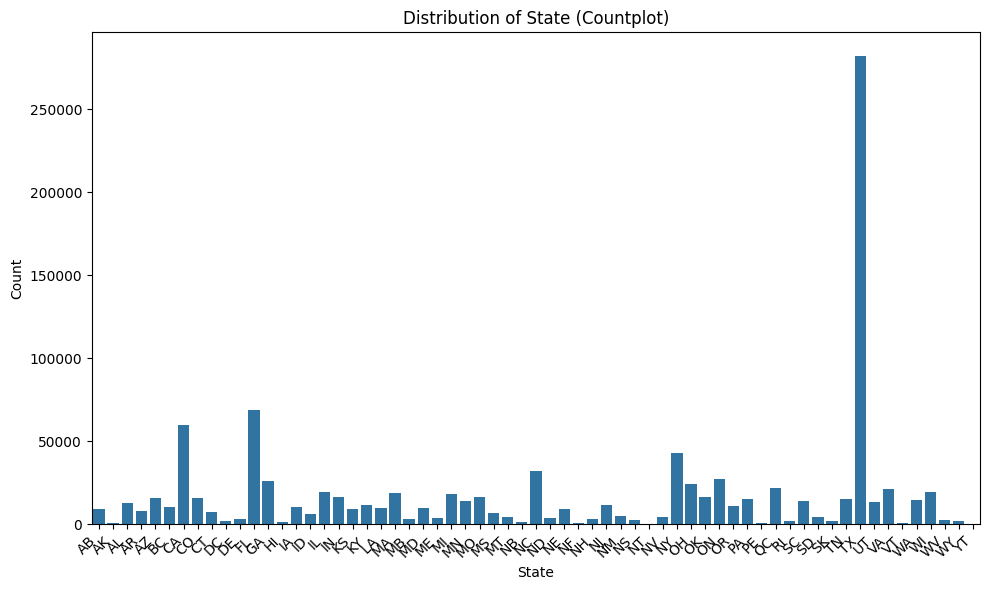

In [38]:
display_column_distribution(filtered_main, 'State')


In [39]:
#filter data for specific values on stage, Primary category, subcategory and valuation as marked by FBM
#create valuation buckets to allow for a more balanced selection across different valuation ranges.
#select data samples with distinct combos of stage, primary category, state and valuation bucket
#Partition by stage, primary category, state and valuation bucket
#selecting number of rows from each partition to get total 130 rows

sample_query='''
WITH FilteredData AS (
  SELECT
    *,
    SAFE_CAST(Valuation_Value AS FLOAT64) AS NumericValuation
  FROM
    `proj-docai-dev.sales_rec_demo.cc_data_total`
  WHERE
    SAFE_CAST(Valuation_Value AS FLOAT64) > 1000000
    AND Stage IN ("Biddate Set", "Construction Documents", "General Contractor Award", "Low Bids Announced", "SUBBIDS: ASAP", "Construction Underway", "Post Bid")
    AND ParentCategories_PrimaryCategoryName IN (
      "Airport", "Apartments", "Auditoriums", "Bank", "College", "University", "Condominiums", "Courthouses", "Dormitories", "Elementary, Pre Schools", "Fire and Police Stations", "Food Stores", "Government - Misc. Bldgs.", "Government Offices", "High Schools", "Hospitals, Clinics", "Hotels", "Junior High Schools", "Libraries", "Medical Offices", "Military - Misc.", "Military Housing", "Military Offices", "Museums", "Nursing Homes", "Offices", "Post Offices", "Prisons", "Religious Auditoriums", "Rental Warehouses", "Restaurants", "Retail Stores", "Shopping Centers", "Special, Vocational Schools", "Sports Arenas/Convention Centers", "Warehouses", "Athletic Bldgs", "Automotive", "Cafeterias", "Clubs, Community Centers", "Entertainment", "Golf Course / Country Club", "Laboratories", "Transportation Terminals", "Water and Sewage Treatment Plants"
    )
    AND EXISTS (SELECT 1 FROM UNNEST(ParentCategories_ParentCategory) AS pc, UNNEST(pc.`ns0:SubCategories`.`ns0:SubCategory`) as sub WHERE sub IN ("Airport","Offices","Transportation Terminals","Rental Warehouses","Museums","Sports Arenas/Convention Centers","Libraries","Auditoriums","Religious Auditoriums","Elementary, Pre Schools, High Schools, Junior High Schools, Special, Vocational Schools","College, University","Clubs, Community Centers", "Athletic Bldgs","Cafeterias","Dormitories","Courthouses","Fire and Police Stations","Prisons","Government - Misc. Bldgs.","Government Offices","Post Offices","Broadcast Studios","Warehouses","Laboratories","Hospitals, Clinics","Medical Offices","Manufacturing"))
),
ValuationBuckets AS (  
    SELECT *, NTILE(4) OVER (ORDER BY NumericValuation) as ValuationBucket
    FROM FilteredData
),
DistinctCombos AS (
  SELECT
    Stage,
    ParentCategories_PrimaryCategoryName,
    ValuationBucket,
    addr.`ns0:StateProvince`,
    COUNT(1) AS combo_count
  FROM
    ValuationBuckets,
    UNNEST(Addresses_Address) AS addr
  GROUP BY 1, 2, 3, 4
),
PartitionedData AS (
  SELECT
    fd.*,
    addr.`ns0:StateProvince`,
    fd.ValuationBucket,
    ROW_NUMBER() OVER (PARTITION BY fd.Stage, fd.ParentCategories_PrimaryCategoryName, addr.`ns0:StateProvince`, fd.ValuationBucket ORDER BY RAND()) AS rn
  FROM
    ValuationBuckets AS fd,
    UNNEST(fd.Addresses_Address) AS addr
),
TargetRows AS (
  SELECT
    CAST(CEIL(130 / (SELECT COUNT(1) FROM DistinctCombos)) AS INT64) AS target_per_group
),
FinalData AS (
    SELECT pd.* from PartitionedData as pd, TargetRows as tr where pd.rn <= tr.target_per_group
)
SELECT * FROM FinalData LIMIT 130;
'''

In [40]:
sample_data = bpd.read_gbq(sample_query)


In [41]:
sample_data.to_csv("data/curated_data/data_sample.csv")

In [47]:
sample_data

,ProjectID,DataSourceID,Title,Stage,URL,UpdateDate,IsProspective,UpdateText,Valuation_Value,Valuation_Currency,...,Parameters_Parameter_SingleTradeClassification,timeCreated,sourceFile,Notes_Note,Details_Detail_Status,NumericValuation,ValuationBucket,ns0:StateProvince,ValuationBucket_1,rn
0,1005528583,US,Pensacola Bay Center - Multi-Use Sports and Ev...,Construction Documents,http://insight.cmdgroup.com/SingleSignOn/Proje...,2020-05-21,False,Core Construction / Sarasota and 2 others were...,3000000.00,USD,...,<NA>,2024-12-01T21:04:47.595Z,1.4_Adhoc_DL_FBMSales_XML_20241003_13.xml,[],[],3000000.0,2,FL,2,1
1,1006678544,US,RFP Construction Manager at Risk - War Memoria...,Post Bid,http://insight.cmdgroup.com/SingleSignOn/Proje...,2023-03-30,False,"Project reviewed, Stage confirmed as Post Bid",8000000.00,USD,...,<NA>,2024-12-02T16:59:11.182Z,1.4_Adhoc_DL_FBMSales_XML_20241003_10.xml,[],[],8000000.0,3,NC,3,1
2,1006343493,US,Cavern Theatre - Phase Four Rehabilitation,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2022-09-17,False,Greer Construction Co. was added as General Co...,1451318.00,USD,...,<NA>,2024-12-02T17:02:56.945Z,1.4_Adhoc_DL_FBMSales_XML_20241009_59.xml,[],[],1451318.0,1,NM,1,1
3,1007323375,US,Coravallis School District #1 Campus PEMB Shell,Post Bid,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-09-24,False,Updated to Post Bid stage,1300000.00,USD,...,<NA>,2024-12-01T21:04:51.598Z,1.4_Adhoc_DL_FBMSales_XML_20241009_304.xml,[],[],1300000.0,1,MT,1,1
4,1006545413,US,Concord,Low Bids Announced,http://insight.cmdgroup.com/SingleSignOn/Proje...,2022-11-18,False,Engineered Construction Services and 2 others ...,1650495.00,USD,...,<NA>,2024-12-01T21:04:50.529Z,1.4_Adhoc_DL_FBMSales_XML_20241009_241.xml,[],[],1650495.0,1,NH,1,1
5,1006004457,US,Denton ISD - Transportation Center East,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2021-07-12,False,Updated to General Contractor Award stage,14000000.00,USD,...,<NA>,2024-12-02T17:02:44.424Z,1.4_Adhoc_DL_FBMSales_XML_20241009_97.xml,[],[],14000000.0,3,TX,3,1
6,1006500496,US,Durand High School - Bid Package 5B - New Audi...,Low Bids Announced,http://insight.cmdgroup.com/SingleSignOn/Proje...,2022-10-13,False,Architectural Glazing Systems Inc and 14 other...,8581627.00,USD,...,<NA>,2024-12-01T21:12:46.641Z,1.4_Adhoc_DL_FBMSales_XML_20241014_43.xml,[],[],8581627.0,3,MI,3,1
7,1007019250,US,RFP Construction Manager at Risk Services - Ne...,Low Bids Announced,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-08-27,False,Project Details or Scope was Added/Updated,2962300.00,USD,...,<NA>,2024-12-02T17:48:45.340Z,1.4_Adhoc_DL_FBMSales_XML_20241125_17.xml,[],[],2962300.0,2,TX,2,1
8,1006774221,CAN,Inspire Bio Innovations Medical and Research S...,Construction Underway,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-01-09,False,Bouthillette Parizeau Inc. was added as Mechan...,25000000.00,CAD,...,<NA>,2024-12-01T21:12:38.440Z,1.4_Adhoc_DL_FBMSales_XML_20241014_15.xml,[],[],25000000.0,4,QC,4,1
9,1006197899,US,Cumberland County Schools Administration Offic...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2022-04-08,False,Superior Mechanical was added as HVAC Contractor,1944000.00,USD,...,<NA>,2024-12-02T16:59:07.593Z,1.4_Adhoc_DL_FBMSales_XML_20241009_155.xml,[],[],1944000.0,1,NC,1,1


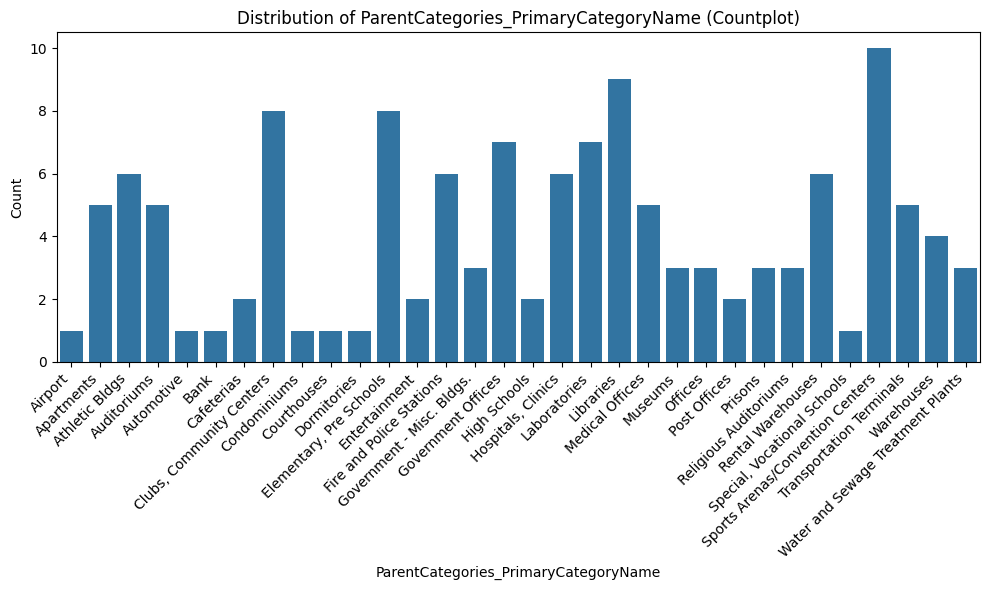

In [42]:
display_column_distribution(sample_data, 'ParentCategories_PrimaryCategoryName')


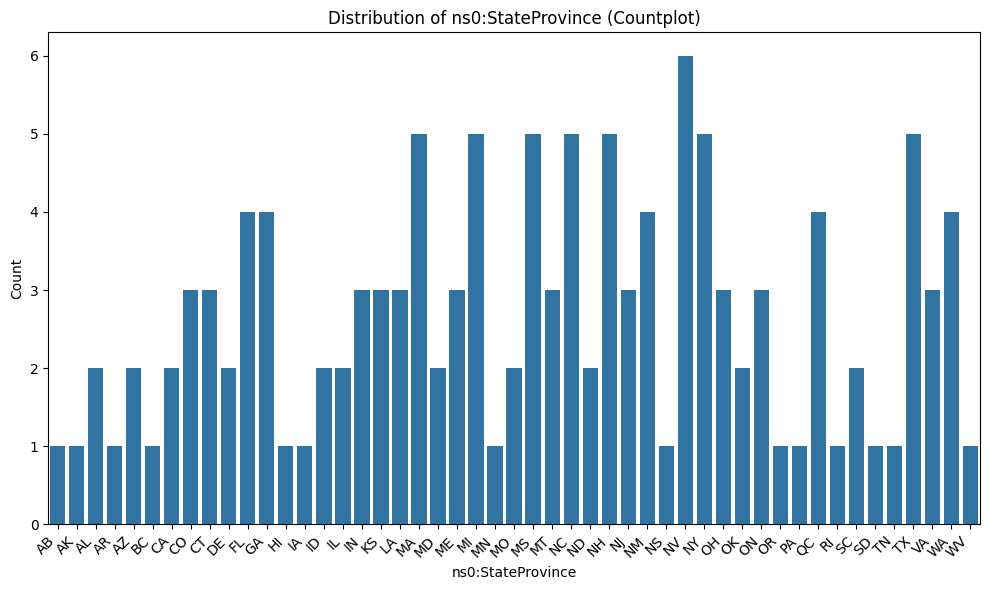

In [43]:
display_column_distribution(sample_data, 'ns0:StateProvince')


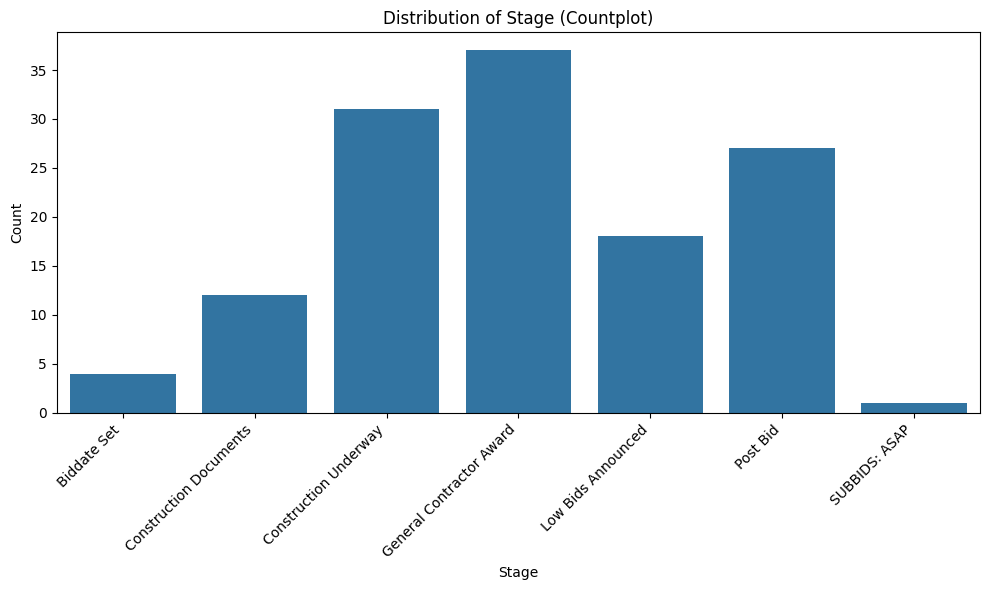

In [44]:
display_column_distribution(sample_data, 'Stage')


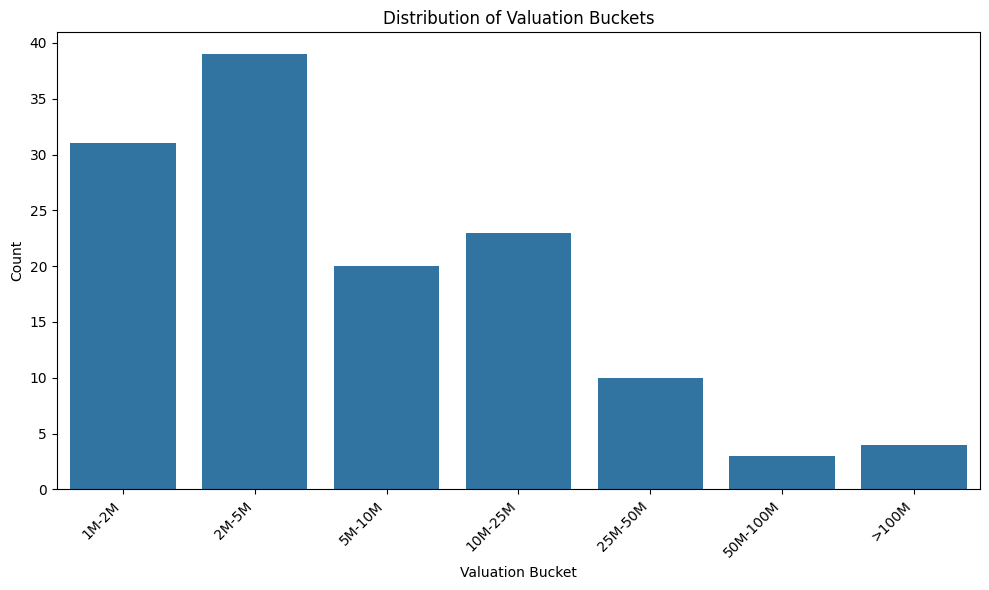

In [46]:
valuation_column = sample_data['NumericValuation'].to_pandas() 

bucket_and_distribute_valuation_series(valuation_column)


In [23]:
import pandas as pd

def create_valuation_buckets_float(df, value_column='NumericValuation', bucket_column='Valuation_buckets'):
    """Creates valuation buckets using pd.cut for a float column."""

    bins = [0, 1000000, 2000000, 5000000, 10000000, 25000000, 50000000, 100000000, float('inf')]
    labels = ['<1M','1M-2M', '2M-5M', '5M-10M', '10M-25M', '25M-50M', '50M-100M', '>100M']

    df[bucket_column] = pd.cut(df[value_column], bins=bins, labels=labels, right=False)

    return df


In [24]:
# Example Usage:
# Create a sample DataFrame

# Apply the function
filtered_main = create_valuation_buckets_float(filtered_main)

# Print the resulting DataFrame
filtered_main

,ProjectID,DataSourceID,Title,Stage,URL,UpdateDate,IsProspective,UpdateText,Valuation_Value,Valuation_Currency,...,AddresLine1,AddressLine2,City,Country,County,State,Zipcode,Latitude,Longitude,Valuation_buckets
0,1005909122,US,RFP D/B - Demo Building 51 Musculo-Skeletal Ce...,Construction Documents,http://insight.cmdgroup.com/SingleSignOn/Proje...,2023-06-02,False,Updated to Construction Documents stage,5000000.00,USD,...,3801 Miranda Ave,<NA>,Palo Alto,UNITED STATES,Santa Clara,CA,94304,37.408130000,-122.158663000,5M-10M
4,1005318816,US,Austin FC Stadium at McKalla Place - Bid Packa...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-04-01,False,"Project reviewed, Stage confirmed as General C...",200000000.00,USD,...,10414 Mc Kalla Pl,<NA>,Austin,UNITED STATES,Travis,TX,78758,30.378845000,-97.711093000,>100M
2,1005318816,US,Austin FC Stadium at McKalla Place - Bid Packa...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-04-01,False,"Project reviewed, Stage confirmed as General C...",200000000.00,USD,...,10414 Mc Kalla Pl,<NA>,Austin,UNITED STATES,Travis,TX,78758,30.378845000,-97.711093000,>100M
3,1005318816,US,Austin FC Stadium at McKalla Place - Bid Packa...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-04-01,False,"Project reviewed, Stage confirmed as General C...",200000000.00,USD,...,10414 Mc Kalla Pl,<NA>,Austin,UNITED STATES,Travis,TX,78758,30.378845000,-97.711093000,>100M
1,1005318816,US,Austin FC Stadium at McKalla Place - Bid Packa...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-04-01,False,"Project reviewed, Stage confirmed as General C...",200000000.00,USD,...,10414 Mc Kalla Pl,<NA>,Austin,UNITED STATES,Travis,TX,78758,30.378845000,-97.711093000,>100M
5,1006083512,US,Poder Learning Center,Construction Underway,http://insight.cmdgroup.com/SingleSignOn/Proje...,2022-06-07,False,Scalaplus was added as Architect,2750000.00,USD,...,3357 W 55th St,<NA>,Chicago,UNITED STATES,Cook,IL,60632,41.808605000,-87.711782000,2M-5M
6,1006866827,US,Construction Services for the Building Additio...,General Contractor Award,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-06-14,False,"Project reviewed, Stage confirmed as General C...",2949000.00,USD,...,26 E Grand Ave,<NA>,Fox Lake,UNITED STATES,Lake,IL,60020,42.394881000,-88.176816000,2M-5M
7,1007200051,CAN,RFQ Contractor D/B - Richmond Hospital Redevel...,Post Bid,http://insight.cmdgroup.com/SingleSignOn/Proje...,2024-07-11,False,Updated to Post Bid stage,1950000000.00,CAD,...,7000 Westminster Hwy,<NA>,Richmond,CANADA,Greater Vancouver RD,BC,V6X 1A1,49.170240000,-123.144920000,>100M
8,1005911347,US,6200 Airport Road-Building 2 - West Jordan Ind...,Post Bid,http://insight.cmdgroup.com/SingleSignOn/Proje...,2022-06-24,False,"Project reviewed, Stage confirmed as Post Bid",10000000.00,USD,...,4701 W 6200 S,<NA>,Salt Lake City,UNITED STATES,Salt Lake,UT,84118,40.654603000,-111.984034000,10M-25M
9,1006708526,US,McCall Road Self Storage Facility,Construction Underway,http://insight.cmdgroup.com/SingleSignOn/Proje...,2023-07-18,False,Updated to Construction Underway stage,12700000.00,USD,...,1918 S McCall Rd,<NA>,Englewood,UNITED STATES,Sarasota,FL,34223,27.013007000,-82.380021000,10M-25M


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_and_plot_distribution(df):
    """
    Calculates the percentage distribution for specified columns and plots them,
    with custom bucketing for 'Valuation_Value', without using Ray.
    """

    columns_to_analyze = ['Stage', 'ParentCategories_PrimaryCategoryName', 'State', 'Valuation_buckets']


    dist_dict = {}
    for col in columns_to_analyze:
        if col in df.columns:
            distribution = df[col].value_counts(normalize=True) * 100
            plt.figure(figsize=(8, 6))
            distribution.plot(kind='bar', color='skyblue')
            plt.title(f'Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel('Percentage')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
            dist_dict[col] = distribution
        else:
            print(f"Column '{col}' not found in the DataFrame.")
    return dist_dict

/Users/Karuna.Gujar/.local/share/mamba/envs/fbm_sales_rec/lib/python3.13/site-packages/bigframes/core/compile/aggregate_compiler.py:167: FutureWarning: `Value.fillna` is deprecated as of v9.1; use fill_null instead
  return bq_sum.fillna(ibis_types.literal(0))


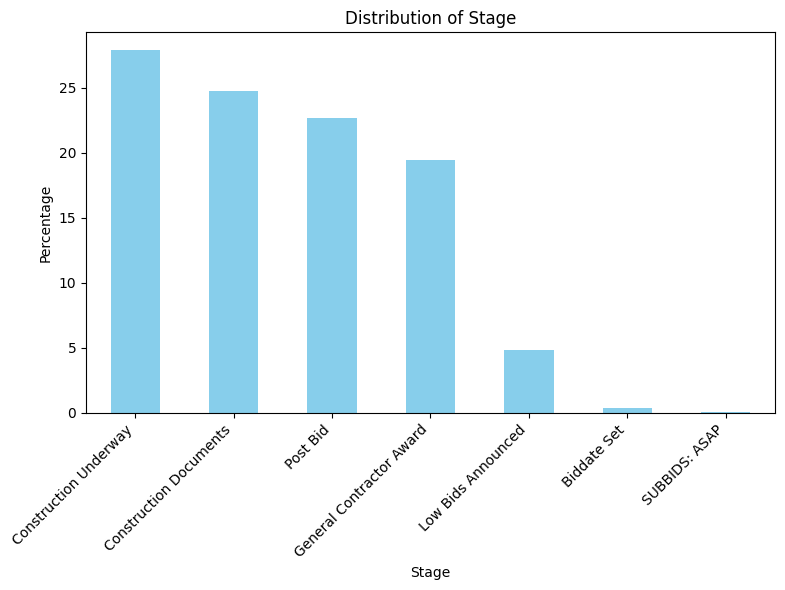

/Users/Karuna.Gujar/.local/share/mamba/envs/fbm_sales_rec/lib/python3.13/site-packages/bigframes/core/compile/aggregate_compiler.py:167: FutureWarning: `Value.fillna` is deprecated as of v9.1; use fill_null instead
  return bq_sum.fillna(ibis_types.literal(0))


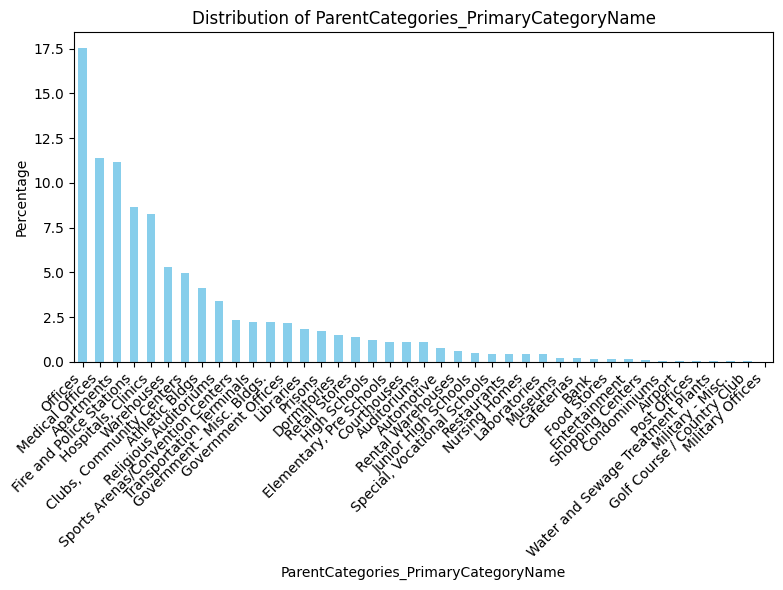

/Users/Karuna.Gujar/.local/share/mamba/envs/fbm_sales_rec/lib/python3.13/site-packages/bigframes/core/compile/aggregate_compiler.py:167: FutureWarning: `Value.fillna` is deprecated as of v9.1; use fill_null instead
  return bq_sum.fillna(ibis_types.literal(0))


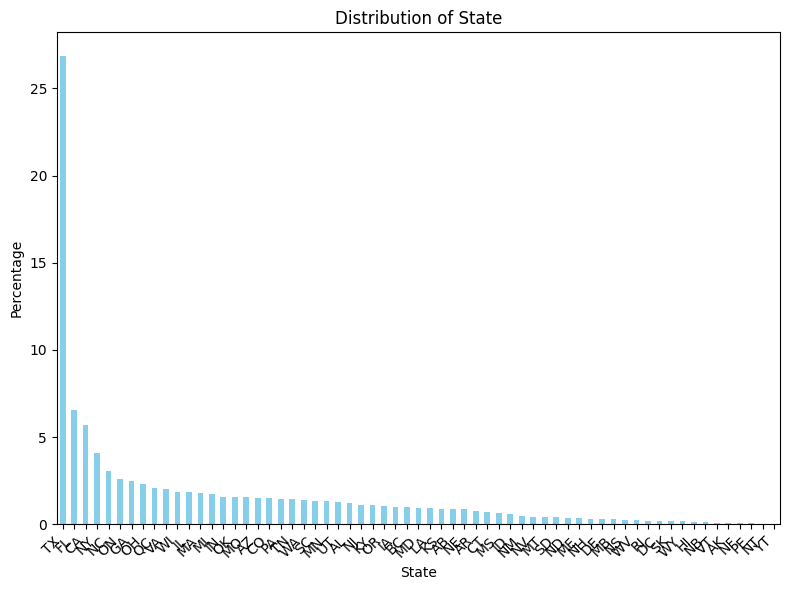

/Users/Karuna.Gujar/.local/share/mamba/envs/fbm_sales_rec/lib/python3.13/site-packages/bigframes/core/compile/aggregate_compiler.py:167: FutureWarning: `Value.fillna` is deprecated as of v9.1; use fill_null instead
  return bq_sum.fillna(ibis_types.literal(0))


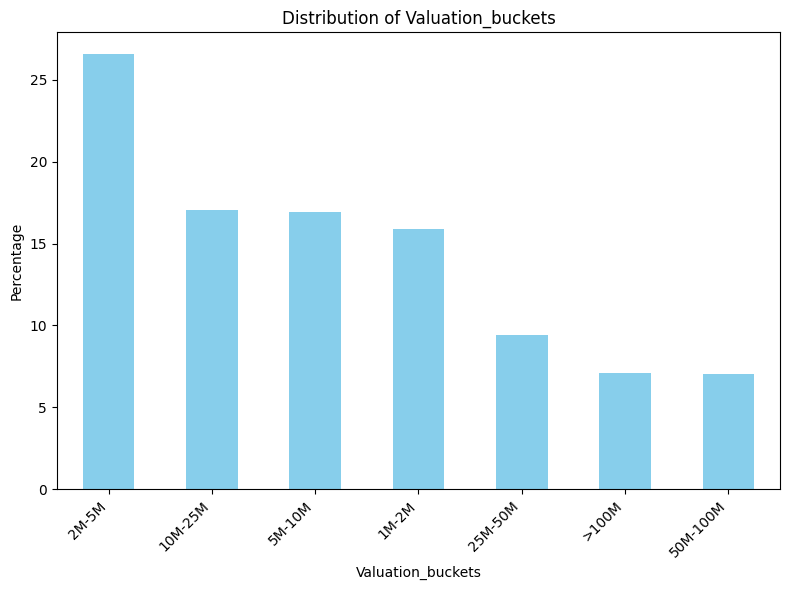

In [32]:
results = calculate_and_plot_distribution(filtered_main)


In [44]:
results.get("Valuation_buckets")

Valuation_buckets
2M-5M       26.567213
10M-25M     17.028917
5M-10M      16.956527
1M-2M       15.869348
25M-50M      9.396565
>100M        7.117337
50M-100M     7.064093
Name: proportion, dtype: Float64

In [40]:
import pandas as pd
import numpy as np
import bigframes.options as bf_options

bf_options.compute.enable_multi_query_execution = True #Enable multi query execution.

def stratified_sample_by_custom_distribution(df, distribution_dict, sample_size):
    """
    Extracts a stratified sample from a DataFrame, matching custom percentage distributions
    for specified columns, with caching.

    Args:
        df (pd.DataFrame): The input DataFrame.
        distribution_dict (dict): A dictionary where keys are column names and values are
                                  dictionaries representing the desired percentage distributions.
        sample_size (int): The desired sample size.

    Returns:
        pd.DataFrame: The stratified sample DataFrame, or None if impossible.
    """

    sampled_rows = []
    remaining_df = df.copy().cache()  # Cache the initial DataFrame

    for col, dist in distribution_dict.items():
        for value, percentage in dist.items():
            expected_count = int(sample_size * percentage)
            if expected_count == 0:
                continue

            matching_rows = remaining_df[(remaining_df[col] == value)].cache()  # Cache the filtered rows

            if len(matching_rows) < expected_count:
                print(f"Warning: Not enough rows with value '{value}' in column '{col}' to satisfy the desired distribution.")
                return None

            sampled_chunk = matching_rows.sample(n=expected_count).cache()  # Cache the sampled chunk
            sampled_rows.append(sampled_chunk)
            remaining_df = remaining_df.drop(sampled_chunk.index).cache()  # Cache the remaining DataFrame

    sampled_df = pd.concat(sampled_rows).cache() #Cache the concatenated dataframe.

    if len(sampled_df) > sample_size:
        sampled_df = sampled_df.sample(n=sample_size).cache() #Cache the final sample.
    elif len(sampled_df) < sample_size:
        print(f"Warning: The final sample size ({len(sampled_df)}) is less than the requested sample size ({sample_size}). Distribution matching was likely impossible.")
        return None

    return sampled_df



ModuleNotFoundError: No module named 'bigframes.options'

In [36]:
sampled_data = stratified_sample_by_custom_distribution(filtered_main, results, 200)


QueryComplexityError: Computation is too complex to execute as a single query. Try using DataFrame.cache() on intermediate results, or setting bigframes.options.compute.enable_multi_query_execution.